# Task 1: Problem Identification

## Problem Type: Image Classification

This dataset represents an image classification problem because each image belongs to one class only:

- dent
- normal
- scratch
- stain

The objective is to predict a single label for each image.

Other computer vision tasks such as object detection or segmentation are not suitable because the dataset does not contain bounding boxes or pixel-level annotations.

# Task 2: Dataset Exploration

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Task 3: Image Preprocessing

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    'images/',
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'images/',
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 408 images belonging to 4 classes.
Found 72 images belonging to 4 classes.


# Task 4: CNN Model Creation

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [10]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 311ms/step - accuracy: 0.2574 - loss: 1.4299 - val_accuracy: 0.2500 - val_loss: 1.3848
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.2500 - loss: 1.3845 - val_accuracy: 0.2500 - val_loss: 1.3776
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.3309 - loss: 1.3585 - val_accuracy: 0.2500 - val_loss: 1.3567
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.3995 - loss: 1.3063 - val_accuracy: 0.5278 - val_loss: 1.2327
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.4755 - loss: 1.1911 - val_accuracy: 0.5278 - val_loss: 1.0401
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.4926 - loss: 1.0371 - val_accuracy: 0.6111 - val_loss: 0.9352
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.5980 - loss: 0.8881 - val_accuracy: 0.7361 - val_loss: 0.7610
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.6912 - loss: 0.7485 - val_accuracy: 0.

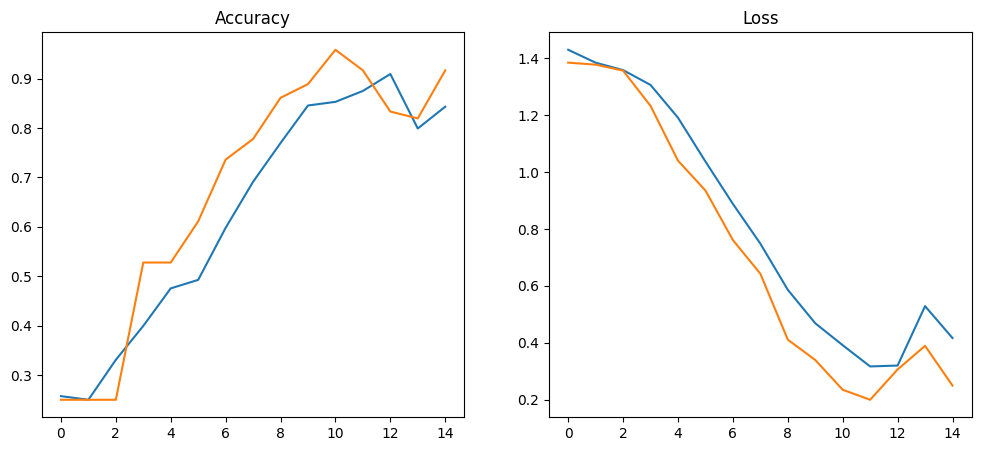

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')

plt.savefig('results/accuracy_loss_curves.png')

plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(validation_generator)

print(test_accuracy)
print(test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9028 - loss: 0.2761 
0.9027777910232544
0.27613362669944763


# Task 6: CNN Concept Explanation

## What is Convolution?

Convolution is a process where filters scan across an image to identify patterns such as edges, textures, and shapes.

## Why is Pooling Used?

Pooling reduces image feature size and computation while keeping important information.

## Why is ReLU Used?

ReLU introduces non-linearity and helps CNNs train faster and more effectively.

## Why are CNNs Better for Images?

CNNs preserve spatial relationships in images and automatically learn useful visual features.

# Task 7: Business Use Case Mapping

## Manufacturing Industry Use Case

This CNN solution can be used in manufacturing for automated defect detection.

The model can classify products as:
- normal
- dented
- scratched
- stained

Benefits include:
- faster inspection
- reduced human error
- improved quality control
- lower operational costs